In [1]:
import pandas as pd
import os
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.dataframe import NWB_to_dataframe
import matplotlib.pylab as plt

import seaborn as sns
from physion.utils import plot_tools as pt



In [313]:
from physion.analysis.process_NWB import EpisodeData

import sys
sys.path.append('../scripts')
from distinct_rest_vs_active import compute_high_movement_cond

import numpy as np
import pandas as pd

sys.path.append('../../src/physion/analysis')
from cross_validation import TwoFold_train_test_split_basic

from sklearn.model_selection import train_test_split

In [14]:
def plot_dFoF_locomotion_all(all_episodes, 
                         all_HMcond, 
                         general=True, 
                         active=True, 
                         resting=True):

    fig, AX = plt.subplots(2, 1, figsize=(4, 2)) 
    fig.subplots_adjust(hspace=0.9)

    num_epi_all = 0
    num_roi_all = 0
    for i in range(len(all_episodes)):
        temp_epi = all_episodes[i].dFoF.shape[0]
        num_epi_all += temp_epi
        temp_roi = all_episodes[i].dFoF.shape[1]
        num_roi_all += temp_roi
    print(f"{len(all_episodes)} files")
    print(f"average of {num_epi_all} episodes ({np.sum(np.concatenate(all_HMcond))} active, {len(np.concatenate(all_HMcond))-np.sum(np.concatenate(all_HMcond))} resting)")
    print(f"average of {num_roi_all} ROIs")

    mean_dFoF = np.mean([ep.dFoF.mean(axis=(0, 1)) for ep in all_ep], axis=0)
    mean_running_speed = np.mean([ep.running_speed.mean(axis=0) for ep in all_ep], axis=0)
    
    mean_dFoF_active = np.mean([ep.dFoF[cond, :, :].mean(axis=(0, 1)) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
    mean_running_active = np.mean([ep.running_speed[cond, :].mean(axis=0) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
    
    mean_dFoF_rest = np.mean([ep.dFoF[~cond, :, :].mean(axis=(0, 1)) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
    mean_running_rest = np.mean([ep.running_speed[~cond, :].mean(axis=0) for ep, cond in zip(all_ep, all_HMcond) if np.any(cond)], axis=0)
  
    if general:
        AX[0].plot(all_ep[0].t, mean_dFoF, color='blue') 
        AX[1].plot(all_ep[0].t, mean_running_speed, color='blue')
    if active: 
        AX[0].plot(all_ep[0].t, mean_dFoF_active, color='orangered') 
        AX[1].plot(all_ep[0].t, mean_running_active, color="orangered")
    if resting: 
        AX[0].plot(all_ep[0].t, mean_dFoF_rest, color = 'grey') 
        AX[1].plot(all_ep[0].t, mean_running_rest, color = "grey")
             
    
    AX[0].set_ylabel('dFoF', fontsize=9)
    AX[1].set_ylabel('locomotion (cm/s)', fontsize=9)

    for ax in AX:
        ax.axvspan(0, 2, color='lightgrey')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.annotate('Visual stimulation', (0.30, 1), color='black', xycoords='axes fraction', va='top', fontsize=7)
        ax.tick_params(axis='both', labelsize=7, pad=1, direction='out', length=4, width=1)
        ax.grid(False)
        ax.tick_params(axis='both', which='both', bottom=True, left=True)
    
    return 0

# NDNF dataset

In [2]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 13.4s) 


In [76]:
all_ep = []
all_HMcond = []

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])
    all_ep.append(ep)

    HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 39/241 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !
  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building epi

14 files
average of 534 episodes (93 active, 441 resting)
average of 3096 ROIs


0

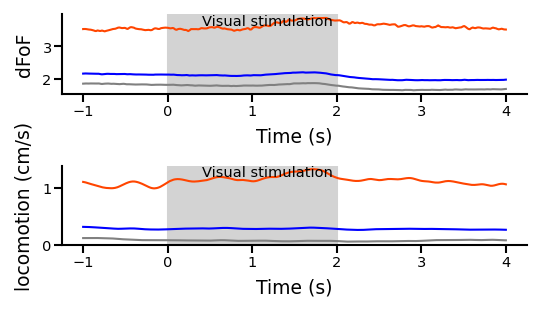

In [16]:
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=True, 
                         active=True, 
                         resting=True)

In [107]:
print(len(all_ep))
print(len(all_HMcond))

for i in range(14):
    print(all_ep[i].dFoF.shape)
    print(all_ep[i].running_speed.shape)
    print(all_HMcond[i].shape)
    print("")

14
14
(40, 53, 4998)
(40, 4998)
(40,)

(40, 36, 4998)
(40, 4998)
(40,)

(40, 66, 4998)
(40, 4998)
(40,)

(39, 142, 4998)
(39, 4998)
(39,)

(40, 379, 4998)
(40, 4998)
(40,)

(40, 289, 4998)
(40, 4998)
(40,)

(40, 212, 4998)
(40, 4998)
(40,)

(40, 351, 4998)
(40, 4998)
(40,)

(40, 105, 4998)
(40, 4998)
(40,)

(40, 449, 4998)
(40, 4998)
(40,)

(40, 412, 4998)
(40, 4998)
(40,)

(40, 251, 4998)
(40, 4998)
(40,)

(40, 271, 4998)
(40, 4998)
(40,)

(15, 80, 4998)
(15, 4998)
(15,)



### Prepare data for the model

In [385]:
rows = []

for file_idx, file in enumerate(all_ep):
    
    for ep_idx in range(file.dFoF.shape[0]):
        
        dFoF_ = file.dFoF[ep_idx].mean(axis=0)
        running_speed_ = file.running_speed[ep_idx].mean(axis=0)
        all_HMcond_ = all_HMcond[file_idx][ep_idx]
        
        row = {'File idx': file_idx,
               'Episode idx': ep_idx,  #would be good to put episode ID, because here it doesn't make sense
               'dFoF_meanROIs': dFoF_.mean(axis=0), 
               'running_speed': running_speed_,
               'behav_state': all_HMcond_}

        for roi_idx in range(file.dFoF[ep_idx].shape[0]):
            row[f'dFoF_ROI_{roi_idx}'] = file.dFoF[ep_idx][roi_idx].mean(axis=0)
            
        rows.append(row)

df_unfolded = pd.DataFrame(rows)

In [386]:
df_unfolded

,File idx,Episode idx,dFoF_meanROIs,running_speed,behav_state,dFoF_ROI_0,dFoF_ROI_1,dFoF_ROI_2,dFoF_ROI_3,dFoF_ROI_4,...,dFoF_ROI_439,dFoF_ROI_440,dFoF_ROI_441,dFoF_ROI_442,dFoF_ROI_443,dFoF_ROI_444,dFoF_ROI_445,dFoF_ROI_446,dFoF_ROI_447,dFoF_ROI_448
0,0,0,5.702647,0.036248,False,2.471014,4.436913,6.336383,5.155571,13.831138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,1.922982,0.004472,False,0.241544,2.169982,2.980326,1.079050,2.749340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2,1.423370,0.003578,False,0.316728,2.615643,1.425230,0.060840,1.058145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3,1.569128,0.019887,False,0.673388,2.287331,0.632433,0.123720,-0.017541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4,1.333883,0.030304,False,0.610407,1.972747,0.351223,0.214799,0.006845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529,13,10,1.237977,0.010728,False,1.621742,8.643528,5.240937,0.370542,-0.173852,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
530,13,11,1.118862,0.000000,False,1.841152,7.677013,4.077533,0.713747,-0.135411,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
531,13,12,1.323067,0.001758,False,1.272253,9.659097,5.143434,0.459606,0.043720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
532,13,13,1.924725,0.011671,False,0.909170,11.221017,0.386977,0.770973,0.418378,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### divide train and test sets

In [387]:
df_train, df_test = train_test_split(df_unfolded,
                                     test_size=0.2,
                                     stratify=df_unfolded['behav_state'],
                                     random_state=42)

In [388]:
#to make sure
print("Train:")
print(f"{df_train['behav_state'].value_counts()} \n")
print(df_train['behav_state'].value_counts(normalize=True))

print("\n\nTest:")
print(f"{df_test['behav_state'].value_counts()} \n")
print(df_test['behav_state'].value_counts(normalize=True))

Train:
behav_state
False    353
True      74
Name: count, dtype: int64 

behav_state
False    0.826698
True     0.173302
Name: proportion, dtype: float64


Test:
behav_state
False    88
True     19
Name: count, dtype: int64 

behav_state
False    0.82243
True     0.17757
Name: proportion, dtype: float64


### create and fit the model

In [372]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression

Mixed linear model

dFoF_meanROIs ~ running_speed  + (1 | File idx) <br>
The model is trying to predict dFoF using the running_speed variable, and accounting for random shifts by file

In [389]:
model_mlm = smf.mixedlm("dFoF_meanROIs ~ running_speed",
                    df_train,
                    groups=df_train["File idx"])
result_mlm = model_mlm.fit()
print(result_mlm.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: dFoF_meanROIs
No. Observations: 427     Method:             REML         
No. Groups:       14      Scale:              2.8677       
Min. group size:  10      Log-Likelihood:     -847.6871    
Max. group size:  35      Converged:          Yes          
Mean group size:  30.5                                     
------------------------------------------------------------
               Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept      1.686     0.277  6.075  0.000   1.142   2.230
running_speed  1.393     0.165  8.464  0.000   1.071   1.716
Group Var      0.942     0.248                              



In [277]:
df_test["_mlm_predicted_dFoF"] = result_mlm.predict(df_test)

Linear regression

In [371]:
model_lr = LinearRegression()

x = df_train["running_speed"].values.reshape(-1, 1)
y = df_train["dFoF_meanROIs"].values
result_lr = model_lr.fit(x, y)

df_test["lr_predicted_dFoF"] = model_lr.predict(df_test["running_speed"].values.reshape(-1, 1))

## Evaluate the predictions

### Mixed linear model

### Mean Squared Error (MSE) / Root Mean Squared Error (RMSE)

In [278]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df_test["dFoF_meanROIs"], df_test["mlm_predicted_dFoF"])
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 1.5135161984615069
RMSE: 1.2302504616790464


In [368]:
mse = mean_squared_error(df_test["dFoF_meanROIs"], df_test["lr_predicted_dFoF"])
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 1.5116222966761055
RMSE: 1.2294804986969519


### R² Score (Coefficient of Determination)

In [366]:
from sklearn.metrics import r2_score

r2 = r2_score(df_test["dFoF_meanROIs"], df_test["mlm_predicted_dFoF"])
print("Mixed linear model R² Score:", r2)

KeyError: 'predicted_dFoF'

In [367]:
r2 = r2_score(df_test["dFoF_meanROIs"], df_test["lr_predicted_dFoF"])
print(f"Linear regression R²: {r2:.3f}")

Linear regression R²: 0.112


### Correlation (Pearson) Between True and Predicted

In [280]:
corr = np.corrcoef(df_test["dFoF_meanROIs"], df_test["mlm_predicted_dFoF"])[0, 1]
print("Correlation (Pearson):", corr)

Correlation (Pearson): 0.39395642191214864


In [369]:
corr = np.corrcoef(df_test["dFoF_meanROIs"], df_test["lr_predicted_dFoF"])[0, 1]
print("Correlation (Pearson):", corr)

Correlation (Pearson): 0.39395642191214836


### Visually: 

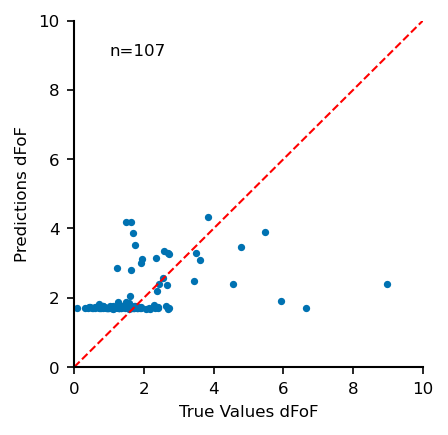

In [310]:
plt.figure(figsize=(3, 3))
plt.scatter(df_test["dFoF_meanROIs"], df_test["mlm_predicted_dFoF"])
plt.plot([0, 10], [0, 10], 'r--')
plt.xlabel('True Values dFoF')
plt.ylabel('Predictions dFoF')
plt.annotate( f"n={len(df_test["dFoF_meanROIs"])}", xy=[1,9])

plt.xlim([0, 10])
plt.ylim([0, 10])
plt.show()

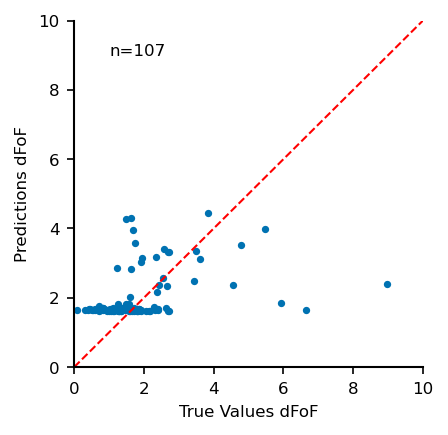

In [370]:
plt.figure(figsize=(3, 3))
plt.scatter(df_test["dFoF_meanROIs"], df_test["lr_predicted_dFoF"])
plt.plot([0, 10], [0, 10], 'r--')
plt.xlabel('True Values dFoF')
plt.ylabel('Predictions dFoF')
plt.annotate( f"n={len(df_test["dFoF_meanROIs"])}", xy=[1,9])

plt.xlim([0, 10])
plt.ylim([0, 10])
plt.show()

# Useless 

In [39]:
index = 8
filename = SESSIONS['files'][index]

df = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['dFoF-ROI%i'%i] = Normalize(data.dFoF[i,:])
C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['dFoF-ROI%i'%i] = Normalize(data.dFoF[i,:])
C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning:

In [40]:
cv_indices = TwoFold_train_test_split_basic(df,spont_act_key='VisStim_grey-10min')

In [48]:
cv_indices

{'spont_train_sets': [array([ 9607,  9608,  9609, ..., 18430, 18431, 18432]),
  array([18433, 18434, 18435, ..., 27257, 27258, 27259])],
 'spont_test_sets': [array([18433, 18434, 18435, ..., 27257, 27258, 27259]),
  array([ 9607,  9608,  9609, ..., 18430, 18431, 18432])],
 'stim_train_sets': [array([    0,     1,     2, ..., 38603, 38604, 38605]),
  array([38606, 38607, 38608, ..., 59556, 59557, 59558])],
 'stim_test_sets': [array([38606, 38607, 38608, ..., 59556, 59557, 59558]),
  array([    0,     1,     2, ..., 38603, 38604, 38605])]}

In [42]:
df

,time,dFoF-ROI0,dFoF-ROI1,dFoF-ROI2,dFoF-ROI3,dFoF-ROI4,dFoF-ROI5,dFoF-ROI6,dFoF-ROI7,dFoF-ROI8,...,VisStim_Natural-Images-4-repeats--Image-ID_2.0,VisStim_Natural-Images-4-repeats--Image-ID_3.0,VisStim_Natural-Images-4-repeats--Image-ID_4.0,VisStim_Natural-Images-4-repeats--Image-ID_5.0,VisStim_grey-10min,VisStim_drifting-gratings--angle_0.0,VisStim_drifting-gratings--angle_90.0,VisStim_drifting-gratings--angle_180.0,VisStim_drifting-gratings--angle_270.0,visualStimFlag
0,0.100000,-0.282056,0.641365,4.104117,-0.643920,-0.524607,0.435839,-0.148795,1.923402,0.199270,...,False,False,False,False,False,False,False,False,False,False
1,0.133987,-0.494832,0.046707,3.911297,-0.607892,-0.446544,0.468803,-0.655050,2.501565,0.203155,...,False,False,False,False,False,False,False,False,False,False
2,0.167974,-0.461588,0.292773,3.744451,-0.320527,-0.408939,0.553050,-0.559740,1.316598,0.223331,...,False,False,False,False,False,False,False,False,False,False
3,0.201962,-0.331059,0.119376,3.950498,-0.767111,-0.432810,0.026938,-0.691292,1.499719,0.424734,...,False,False,False,False,False,False,False,False,False,False
4,0.235949,-0.167904,0.417386,3.996563,-0.287895,-0.403449,-0.766347,-0.520022,2.291666,0.435279,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59554,2024.176270,-1.014207,-0.604653,-0.044735,-0.955254,-0.028992,-0.363451,-0.819654,-0.576631,-1.231678,...,False,False,False,False,False,False,False,False,False,False
59555,2024.210257,-0.982247,-0.209354,-0.095545,-1.015700,-0.318654,-0.260342,-0.831963,-0.608653,-1.269033,...,False,False,False,False,False,False,False,False,False,False
59556,2024.244244,-1.112391,-0.319656,-0.075564,-0.956486,-0.524712,-0.567471,-0.342942,0.348468,-1.264352,...,False,False,False,False,False,False,False,False,False,False
59557,2024.278231,-1.135471,-0.391810,-0.147224,-0.922328,-0.134450,-0.620590,-0.553103,0.119309,-1.271437,...,False,False,False,False,False,False,False,False,False,False


In [51]:
cv_indices['spont_train_sets']

[array([ 9607,  9608,  9609, ..., 18430, 18431, 18432]),
 array([18433, 18434, 18435, ..., 27257, 27258, 27259])]

In [41]:
md = smf.mixedlm("dFoF ~ running_speed", df, groups = df['behav_state'])
mdf = md.fit()
print(mdf.summary())

KeyError: 'behav_state'

In [3]:
index = 8
filename = SESSIONS['files'][index]

In [324]:
df_ = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['dFoF-ROI%i'%i] = Normalize(data.dFoF[i,:])
C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['dFoF-ROI%i'%i] = Normalize(data.dFoF[i,:])
C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning:

In [325]:
df_

,time,dFoF-ROI0,dFoF-ROI1,dFoF-ROI2,dFoF-ROI3,dFoF-ROI4,dFoF-ROI5,dFoF-ROI6,dFoF-ROI7,dFoF-ROI8,...,VisStim_Natural-Images-4-repeats--Image-ID_2.0,VisStim_Natural-Images-4-repeats--Image-ID_3.0,VisStim_Natural-Images-4-repeats--Image-ID_4.0,VisStim_Natural-Images-4-repeats--Image-ID_5.0,VisStim_grey-10min,VisStim_drifting-gratings--angle_0.0,VisStim_drifting-gratings--angle_90.0,VisStim_drifting-gratings--angle_180.0,VisStim_drifting-gratings--angle_270.0,visualStimFlag
0,0.100000,-0.282056,0.641365,4.104117,-0.643920,-0.524607,0.435839,-0.148795,1.923402,0.199270,...,False,False,False,False,False,False,False,False,False,False
1,0.133987,-0.494832,0.046707,3.911297,-0.607892,-0.446544,0.468803,-0.655050,2.501565,0.203155,...,False,False,False,False,False,False,False,False,False,False
2,0.167974,-0.461588,0.292773,3.744451,-0.320527,-0.408939,0.553050,-0.559740,1.316598,0.223331,...,False,False,False,False,False,False,False,False,False,False
3,0.201962,-0.331059,0.119376,3.950498,-0.767111,-0.432810,0.026938,-0.691292,1.499719,0.424734,...,False,False,False,False,False,False,False,False,False,False
4,0.235949,-0.167904,0.417386,3.996563,-0.287895,-0.403449,-0.766347,-0.520022,2.291666,0.435279,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59554,2024.176270,-1.014207,-0.604653,-0.044735,-0.955254,-0.028992,-0.363451,-0.819654,-0.576631,-1.231678,...,False,False,False,False,False,False,False,False,False,False
59555,2024.210257,-0.982247,-0.209354,-0.095545,-1.015700,-0.318654,-0.260342,-0.831963,-0.608653,-1.269033,...,False,False,False,False,False,False,False,False,False,False
59556,2024.244244,-1.112391,-0.319656,-0.075564,-0.956486,-0.524712,-0.567471,-0.342942,0.348468,-1.264352,...,False,False,False,False,False,False,False,False,False,False
59557,2024.278231,-1.135471,-0.391810,-0.147224,-0.922328,-0.134450,-0.620590,-0.553103,0.119309,-1.271437,...,False,False,False,False,False,False,False,False,False,False


In [5]:
data = Data(filename, verbose=False)
data.build_dFoF()
data.t_dFoF[-1]
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pupil_size_dFoF_sampled = data.build_pupil_diameter(specific_time_sampling=data.t_dFoF)

df = pd.DataFrame()
df['dFoF'] = data.dFoF.mean(axis=0)   #average of all ROIs
df['running_speed'] = running_dFoF_sampled
df['behav_state'] = df['running_speed'].apply(lambda speed: True if speed > 0.1 else False)
df['stim_cond'] = (~df_['VisStim_grey-10min'])

print(df)


calculating dF/F with method "percentile" [...]

  ** 15 ROIs were discarded with the positive F0 criterion (12.5%) ** 

-> dFoF calculus done !  (calculation took 0.1s)
           dFoF  running_speed  behav_state  stim_cond
0      2.031212       0.000000        False       True
1      2.109512       0.000000        False       True
2      1.762196       0.000000        False       True
3      1.472235       0.000000        False       True
4      1.575318       0.000000        False       True
...         ...            ...          ...        ...
59554  0.919641       0.169372         True       True
59555  1.065641       0.169372         True       True
59556  1.080562       0.169372         True       True
59557  0.971785       0.169372         True       True
59558  1.102477       0.169372         True       True

[59559 rows x 4 columns]


Text(0, 0.5, 'dFoF')

<Figure size 1200x300 with 0 Axes>

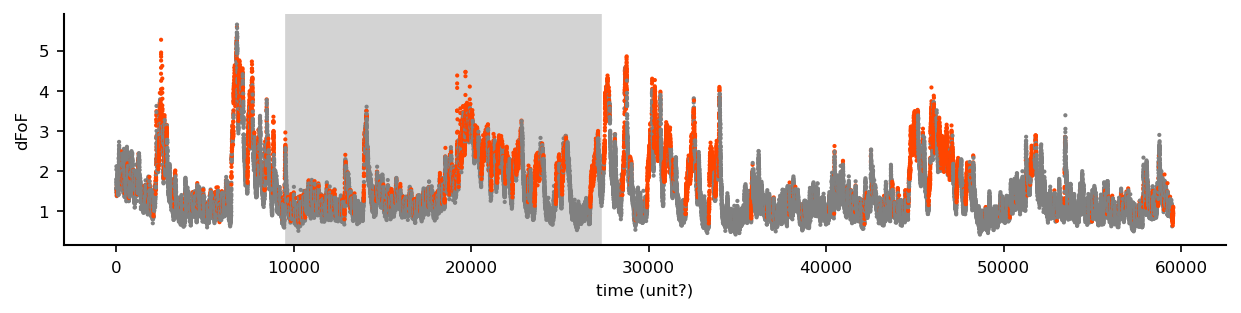

False False
False True
True False
True True


<Figure size 750x300 with 0 Axes>

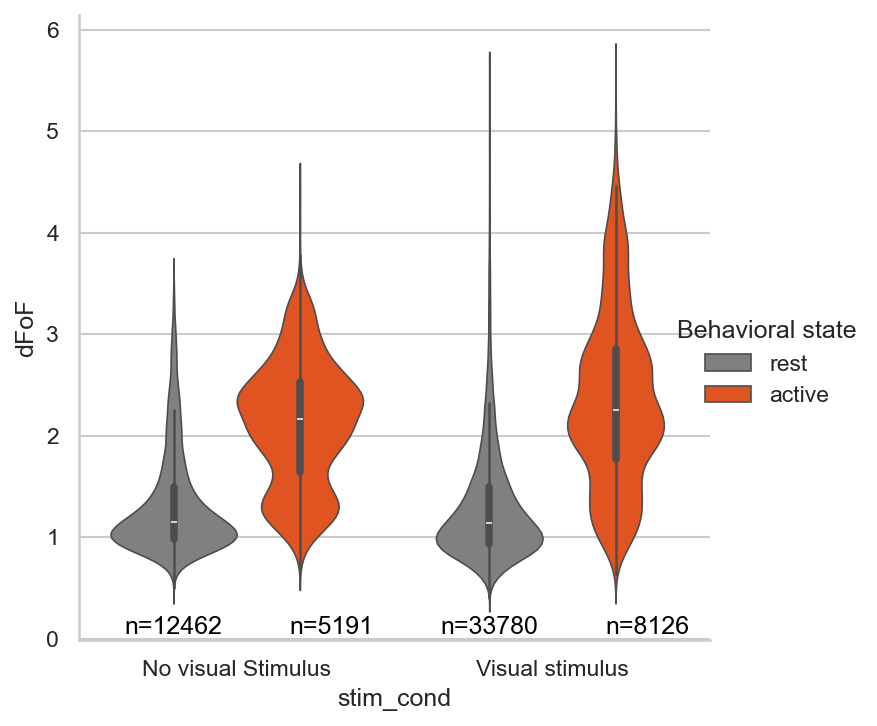

In [7]:
# Set plot style
sns.set(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(5, 2))
g = sns.catplot(data=df, 
                 kind = 'violin',
                 x='stim_cond', 
                 y='dFoF', 
                 hue='behav_state', 
                 palette=['grey', 'orangered'], 
                 linewidth=0.8, 
                 legend_out = True)

g.set_xticklabels(["No visual Stimulus", "Visual stimulus"])
new_title = 'Behavioral state'
g._legend.set_title(new_title)
new_labels = ['rest', 'active']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    

ax = g.ax  # Get the matplotlib axis
grouped = df.groupby(["stim_cond", "behav_state"]).size().reset_index(name='count')
for i, (x, hue) in enumerate(zip(grouped["stim_cond"], grouped["behav_state"])):
    print(x, hue)
    n = grouped.loc[(grouped["stim_cond"] == x) & (grouped["behav_state"] == hue), "count"].values[0]
    ax.text(i/2-0.2, 0, f"n={n}", ha="center", va="bottom", fontsize=12, color="black")




plt.show()

Statistics: Linear Mixed effect model

In [142]:
md = smf.mixedlm("dFoF ~ behav_state", df, groups=df['stim_cond'])
mdf = md.fit()
print(mdf.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  dFoF       
No. Observations:    59559    Method:              REML       
No. Groups:          2        Scale:               0.3627     
Min. group size:     17653    Log-Likelihood:      -54323.0632
Max. group size:     41906    Converged:           Yes        
Mean group size:     29779.5                                  
--------------------------------------------------------------
                    Coef. Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           1.298    0.019  66.627 0.000  1.259  1.336
behav_state[T.True] 0.962    0.006 161.413 0.000  0.950  0.974
Group Var           0.001    0.002                            



C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 2 Way-ANOVA

Assumptions
1) Homogeneity of variance (a.k.a. homoscedasticity)
The variation around the mean for each group being compared should be similar among all groups. If your data don’t meet this assumption, you may be able to use a non-parametric alternative, like the Kruskal-Wallis test.

2) Independence of observations
Your independent variables should not be dependent on one another (i.e. one should not cause the other). This is impossible to test with categorical variables – it can only be ensured by good experimental design. <br>
In addition, your dependent variable should represent unique observations – that is, your observations should not be grouped within locations or individuals.<br>
If your data don’t meet this assumption (i.e. if you set up experimental treatments within blocks), you can include a blocking variable and/or use a repeated-measures ANOVA.<br>

3) Normally-distributed dependent variable
The values of the dependent variable should follow a bell curve (they should be normally distributed). If your data don’t meet this assumption, you can try a data transformation.


In [141]:
# Performing two-way ANOVA 
md = ols('dFoF ~ C(stim_cond) + C(behav_state) + C(stim_cond):C(behav_state)', data=df)
mdf = md.fit()
result = sm.stats.anova_lm(mdf, type=2)  
print(result) 

                                  df        sum_sq      mean_sq             F  \
C(stim_cond)                     1.0     41.028117    41.028117    113.969296   
C(behav_state)                   1.0   9455.124074  9455.124074  26264.764682   
C(stim_cond):C(behav_state)      1.0    164.489856   164.489856    456.925507   
Residual                     59555.0  21439.366430     0.359993           NaN   

                                    PR(>F)  
C(stim_cond)                  1.398817e-26  
C(behav_state)                0.000000e+00  
C(stim_cond):C(behav_state)  5.386488e-101  
Residual                               NaN  


dFoF significantly affected by the behavioral state, stimulus condition, and the interaction between the 2?

In [ ]:
all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])
    all_ep.append(ep)

    HMcond = compute_high_movement_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

In [ ]:
print(df)

In [317]:
print(len(all_ep))
print(len(all_HMcond))
print(all_ep[0].dFoF.shape)
print(all_ep[0].running_speed.shape)
print(all_HMcond[0].shape)

df_test = pd.DataFrame()
df_test['dFoF'] = [all_ep[i].dFoF for i in range(len(all_ep))]
df_test['running_speed'] = [all_ep[i].running_speed for i in range(len(all_ep))]
df_test['behav_state'] = all_HMcond

14
14
(40, 53, 4998)
(40, 4998)
(40,)


In [318]:
df_test

,dFoF,running_speed,behav_state
0,"[[[3.0389026091975087, 3.0274941436044465, 3.0...","[[0.323525973880979, 0.3232326692360436, 0.322...","[False, False, False, False, False, False, Fal..."
1,"[[[4.824590233510973, 4.809067987642326, 4.793...","[[1.8263223291436887, 1.825851816622686, 1.825...","[False, False, False, True, False, True, True,..."
2,"[[[15.523146804080064, 15.776813471032138, 16....","[[1.6373258301680982, 1.628871023649651, 1.620...","[False, False, False, False, False, False, Fal..."
3,"[[[-0.373225019060431, -0.35334796179939965, -...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[False, False, False, True, False, False, Fals..."
4,"[[[1.9133715529946516, 1.9138207124161726, 1.9...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[False, False, False, False, False, False, Tru..."
5,"[[[2.629197111185788, 2.633721892185675, 2.638...","[[0.4170574902834871, 0.4166662351186154, 0.41...","[True, False, False, False, False, False, Fals..."
6,"[[[3.7401281245207274, 3.7475704276305786, 3.7...","[[0.0632313674610055, 0.06524245859280646, 0.0...","[False, False, False, False, False, False, Fal..."
7,"[[[0.926868458563169, 0.9278902672706805, 0.92...","[[0.13254066358405153, 0.13209552579108746, 0....","[False, False, False, False, False, False, Fal..."
8,"[[[0.14569651655960753, 0.14991202215920282, 0...","[[0.03426995796547808, 0.033873869668008774, 0...","[False, False, False, False, False, False, Fal..."
9,"[[[12.820496675054518, 12.850033819826027, 12....","[[1.588160348453467, 1.5904728465931535, 1.592...","[True, False, False, False, False, True, True,..."
